In [1]:
import torch

if torch.cuda.is_available():
    device = 'cuda'
    print(f'CUDA device name: {torch.cuda.get_device_name()}')
else:
    device = 'cpu'
    print(f'using CPU')

CUDA device name: NVIDIA GeForce RTX 2060


In [14]:
img_t = torch.rand(3, 5, 5)
print(img_t.shape)
img_t

torch.Size([3, 5, 5])


tensor([[[0.7075, 0.4548, 0.5205, 0.9664, 0.3938],
         [0.9496, 0.5240, 0.5761, 0.2368, 0.7017],
         [0.5150, 0.2734, 0.9957, 0.6215, 0.5238],
         [0.5982, 0.8384, 0.2394, 0.5490, 0.8242],
         [0.1991, 0.9614, 0.8892, 0.2462, 0.2953]],

        [[0.2668, 0.7153, 0.8368, 0.8164, 0.1130],
         [0.0140, 0.5224, 0.6743, 0.8803, 0.8721],
         [0.4119, 0.5116, 0.5461, 0.5515, 0.8222],
         [0.4324, 0.1967, 0.9989, 0.9889, 0.1107],
         [0.4093, 0.3961, 0.8156, 0.9905, 0.7836]],

        [[0.1396, 0.6465, 0.4742, 0.5994, 0.5637],
         [0.6749, 0.9190, 0.7174, 0.9821, 0.5327],
         [0.7583, 0.5044, 0.1422, 0.2522, 0.0953],
         [0.2699, 0.4698, 0.8534, 0.9624, 0.6719],
         [0.7009, 0.5316, 0.4417, 0.3290, 0.2530]]])

In [15]:
weights = torch.tensor([0.2126, 0.7152, 0.0722])
print(weights.shape)
weights

torch.Size([3])


tensor([0.2126, 0.7152, 0.0722])

In [4]:
batch_t = torch.rand(2, 3, 5, 5)
print(batch_t.dtype)
batch_t

torch.float32


tensor([[[[0.6473, 0.6415, 0.6066, 0.1764, 0.5522],
          [0.1181, 0.8012, 0.5480, 0.3537, 0.7473],
          [0.5273, 0.4265, 0.3057, 0.1500, 0.7631],
          [0.9645, 0.3998, 0.5586, 0.8280, 0.6065],
          [0.0950, 0.2867, 0.4867, 0.2283, 0.1530]],

         [[0.5949, 0.7153, 0.6085, 0.1491, 0.2946],
          [0.4752, 0.8217, 0.4824, 0.5496, 0.4793],
          [0.9508, 0.2133, 0.3867, 0.9180, 0.6431],
          [0.9535, 0.8449, 0.0484, 0.0762, 0.9835],
          [0.1481, 0.7693, 0.2577, 0.4043, 0.1105]],

         [[0.1192, 0.3342, 0.9636, 0.2316, 0.7207],
          [0.9823, 0.8274, 0.0494, 0.0457, 0.0414],
          [0.1811, 0.8788, 0.0633, 0.8068, 0.4238],
          [0.2490, 0.0884, 0.0545, 0.6938, 0.8084],
          [0.6046, 0.2671, 0.8134, 0.1661, 0.9691]]],


        [[[0.3151, 0.1365, 0.2745, 0.7284, 0.8161],
          [0.9605, 0.6938, 0.4672, 0.7803, 0.6405],
          [0.1856, 0.1105, 0.1240, 0.1283, 0.9210],
          [0.7644, 0.7822, 0.8876, 0.7674, 0.3120],
    

In [5]:
img_gray_naive = img_t.mean(-3)
img_gray_naive

tensor([[0.4765, 0.6088, 0.4394, 0.6671, 0.5066],
        [0.7903, 0.4773, 0.6822, 0.6233, 0.4390],
        [0.3725, 0.5256, 0.4272, 0.7136, 0.3784],
        [0.2352, 0.5970, 0.3337, 0.8534, 0.7266],
        [0.7540, 0.4107, 0.6709, 0.7186, 0.5586]])

In [6]:
batch_gray_naive = batch_t.mean(-3)
batch_gray_naive

tensor([[[0.4538, 0.5636, 0.7263, 0.1857, 0.5225],
         [0.5252, 0.8168, 0.3599, 0.3163, 0.4227],
         [0.5531, 0.5062, 0.2519, 0.6250, 0.6100],
         [0.7224, 0.4444, 0.2205, 0.5327, 0.7995],
         [0.2826, 0.4411, 0.5193, 0.2662, 0.4109]],

        [[0.4096, 0.0979, 0.3764, 0.7810, 0.7827],
         [0.6383, 0.3979, 0.3777, 0.7876, 0.4378],
         [0.3335, 0.2097, 0.2776, 0.3638, 0.3623],
         [0.7026, 0.7219, 0.7899, 0.5183, 0.3074],
         [0.6239, 0.5361, 0.3738, 0.6288, 0.4802]]])

In [7]:
img_gray_naive.shape, batch_gray_naive.shape

(torch.Size([5, 5]), torch.Size([2, 5, 5]))

In [13]:
unsqueezed_weights = weights.unsqueeze(-1).unsqueeze(-1)
print(unsqueezed_weights.shape)
unsqueezed_weights

torch.Size([3, 1, 1])


tensor([[[0.2126]],

        [[0.7152]],

        [[0.0722]]])

In [9]:
img_weights = (img_t * unsqueezed_weights)
batch_weights = (batch_t * unsqueezed_weights)
img_gray_weighted = img_weights.sum(-3)
batch_gray_weighted = batch_weights.sum(-3)

In [16]:
print(img_weights.shape)
img_weights

torch.Size([3, 5, 5])


tensor([[[0.1024, 0.1634, 0.0392, 0.2082, 0.0644],
         [0.0909, 0.0644, 0.1451, 0.0396, 0.0998],
         [0.1200, 0.0654, 0.0599, 0.0940, 0.1291],
         [0.0067, 0.1341, 0.0307, 0.1745, 0.1941],
         [0.1616, 0.1673, 0.0501, 0.1658, 0.1399]],

        [[0.4198, 0.3257, 0.5502, 0.1577, 0.6369],
         [0.6958, 0.1578, 0.7144, 0.6579, 0.3905],
         [0.0738, 0.6569, 0.3785, 0.7068, 0.3029],
         [0.1347, 0.5420, 0.2937, 0.6821, 0.6092],
         [0.5972, 0.2177, 0.6841, 0.3464, 0.6660]],

        [[0.0261, 0.0435, 0.0263, 0.0579, 0.0236],
         [0.0701, 0.0656, 0.0264, 0.0551, 0.0218],
         [0.0325, 0.0253, 0.0340, 0.0513, 0.0075],
         [0.0350, 0.0291, 0.0322, 0.0567, 0.0300],
         [0.0482, 0.0102, 0.0593, 0.0644, 0.0063]]])

In [18]:
print(batch_weights.shape)
batch_weights

torch.Size([2, 3, 5, 5])


tensor([[[[0.1376, 0.1364, 0.1290, 0.0375, 0.1174],
          [0.0251, 0.1703, 0.1165, 0.0752, 0.1589],
          [0.1121, 0.0907, 0.0650, 0.0319, 0.1622],
          [0.2051, 0.0850, 0.1188, 0.1760, 0.1289],
          [0.0202, 0.0609, 0.1035, 0.0485, 0.0325]],

         [[0.4255, 0.5116, 0.4352, 0.1066, 0.2107],
          [0.3399, 0.5877, 0.3450, 0.3931, 0.3428],
          [0.6800, 0.1525, 0.2765, 0.6566, 0.4600],
          [0.6820, 0.6042, 0.0346, 0.0545, 0.7034],
          [0.1059, 0.5502, 0.1843, 0.2892, 0.0790]],

         [[0.0086, 0.0241, 0.0696, 0.0167, 0.0520],
          [0.0709, 0.0597, 0.0036, 0.0033, 0.0030],
          [0.0131, 0.0634, 0.0046, 0.0583, 0.0306],
          [0.0180, 0.0064, 0.0039, 0.0501, 0.0584],
          [0.0437, 0.0193, 0.0587, 0.0120, 0.0700]]],


        [[[0.0670, 0.0290, 0.0584, 0.1549, 0.1735],
          [0.2042, 0.1475, 0.0993, 0.1659, 0.1362],
          [0.0395, 0.0235, 0.0264, 0.0273, 0.1958],
          [0.1625, 0.1663, 0.1887, 0.1631, 0.0663],
    

In [21]:
print(img_gray_weighted.shape)
img_gray_weighted

torch.Size([5, 5])


tensor([[0.5483, 0.5326, 0.6158, 0.4238, 0.7248],
        [0.8567, 0.2878, 0.8859, 0.7527, 0.5121],
        [0.2263, 0.7477, 0.4724, 0.8520, 0.4396],
        [0.1765, 0.7051, 0.3566, 0.9134, 0.8333],
        [0.8069, 0.3951, 0.7934, 0.5765, 0.8122]])

In [22]:
print(batch_gray_weighted.shape)
batch_gray_weighted

torch.Size([2, 5, 5])


tensor([[[0.5717, 0.6721, 0.6338, 0.1608, 0.3802],
         [0.4359, 0.8178, 0.4651, 0.4715, 0.5046],
         [0.8052, 0.3067, 0.3461, 0.7467, 0.6528],
         [0.9050, 0.6956, 0.1573, 0.2806, 0.8907],
         [0.1698, 0.6305, 0.3465, 0.3497, 0.1815]],

        [[0.4535, 0.1313, 0.3258, 0.8802, 0.9066],
         [0.2927, 0.3530, 0.3360, 0.7481, 0.4785],
         [0.6044, 0.3515, 0.1828, 0.3782, 0.2599],
         [0.6108, 0.8197, 0.6343, 0.5302, 0.3170],
         [0.3483, 0.5246, 0.1721, 0.5237, 0.7862]]])

In [23]:
img_named = img_t.refine_names('channels', 'rows', 'columns')
img_named.shape, img_named.names

c:\Users\neucl\Dev\Thesis\cxr-diff-vqa\cxr-env\Lib\site-packages\torch\_tensor.py:1240: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at ..\c10/core/TensorImpl.h:1924.)
  return super().refine_names(names)


(torch.Size([3, 5, 5]), ('channels', 'rows', 'columns'))

In [24]:
batch_named = batch_t.refine_names(...,'channels', 'rows', 'columns')
batch_named.shape, batch_named.names

(torch.Size([2, 3, 5, 5]), (None, 'channels', 'rows', 'columns'))

In [25]:
weights_named = weights.refine_names('channels')
weights_aligned = weights_named.align_as(img_named)
print(weights_aligned.shape)
print(weights_aligned.names)
weights_aligned

torch.Size([3, 1, 1])
('channels', 'rows', 'columns')


tensor([[[0.2126]],

        [[0.7152]],

        [[0.0722]]], names=('channels', 'rows', 'columns'))

In [ ]:
gray_named = (img_named * weights_aligned).sum('channels')
print(gray_named.shape)
print(gray_named.names)
gray_named

torch.Size([5, 5])
('rows', 'columns')


tensor([[0.3513, 0.6549, 0.7434, 0.8326, 0.2052],
        [0.2607, 0.5514, 0.6566, 0.7508, 0.8114],
        [0.4588, 0.4604, 0.6125, 0.5448, 0.7063],
        [0.4559, 0.3528, 0.8270, 0.8934, 0.3029],
        [0.3857, 0.5261, 0.8042, 0.7845, 0.6415]], names=('rows', 'columns'))

In [39]:
#C:\\Users\\neucl\\Pictures
from PIL import Image
from torchvision import transforms

img_to_tensor = transforms.ToTensor()
tensor_to_img = transforms.ToPILImage()

try:
    img_path = 'C:\\Users\\neucl\\Pictures\\me.jpg'
    pil_image = Image.open(img_path)

    weights = torch.rand([3]).unsqueeze(-1).unsqueeze(-1)

    tensor_image = img_to_tensor(pil_image)

    weighted_img = tensor_image * weights

    # tensor_image_gray = tensor_image.mean(-3)

    pil_img_gray = tensor_to_img(weighted_img)

    print(tensor_image.shape)

except FileNotFoundError as e:
    print(str(e))

except Exception as e:
    print(str(e))

torch.Size([3, 220, 220])


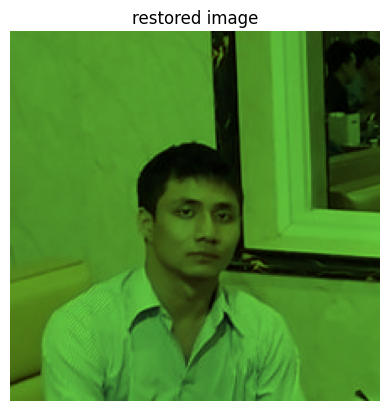

In [40]:
from matplotlib import pyplot as plt

plt.imshow(pil_img_gray)
plt.title('restored image')
plt.axis('off')
plt.show()